In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\aps_failure_training_set1.csv",na_values='na')
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,0.0,182.0,NaN,0.0,0.0,0.0,0.0,0.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,NaN,2926.0,NaN,0.0,0.0,0.0,0.0,222.0,...,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,NaN,1594.0,1052.0,0.0,0.0,0.0,244.0,178226.0,...,1432098.0,372252.0,527514.0,358274.0,332818.0,284178.0,3742.0,0.0,0.0,0.0
3,pos,762958,NaN,NaN,NaN,NaN,NaN,776.0,281128.0,2186308.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pos,695994,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,1397742.0,495544.0,361646.0,28610.0,5130.0,212.0,0.0,0.0,NaN,NaN


In [4]:
df.shape

(36188, 171)

In [5]:

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pandas as pd
import seaborn as sns
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import warnings

In [6]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 170 numerical features : ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000'

([], [])

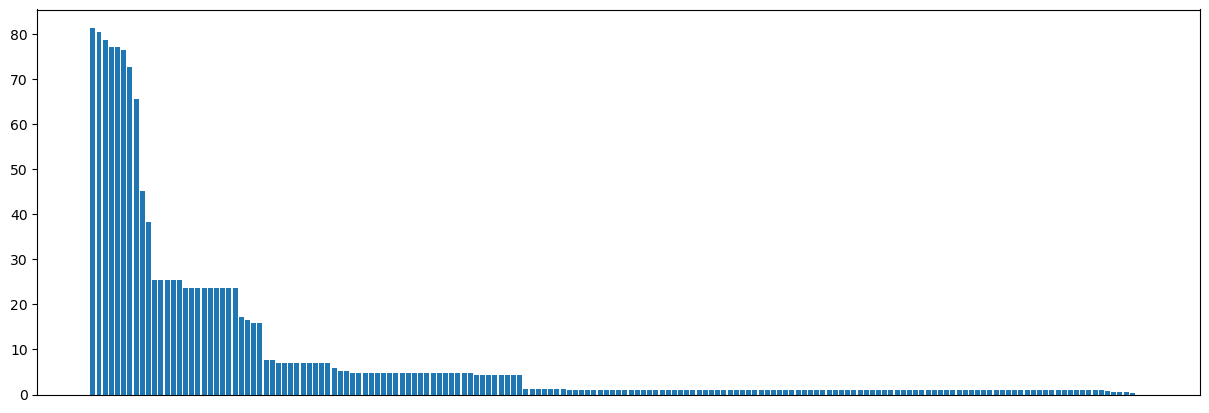

In [8]:
#plotting missing value count for each column
fig, ax = plt.subplots(figsize=(15, 5))

missing = df.isnull().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0, ascending=False)

ax.bar(missing.index, missing.values.T[0])
plt.xticks([])

In [9]:
#droping column which has more than 70% missing values
dropcols=missing[missing[0]>70]
dropcols


,0
br_000,81.410965
bq_000,80.501824
bp_000,78.794075
ab_000,77.086327
cr_000,77.086327
bo_000,76.533658
bn_000,72.761689


In [10]:
df.drop(dropcols.index,inplace=True,axis=1)

In [11]:
df.shape

(36188, 164)

In [12]:
missing_values_count=df.isnull().sum()
total_cells=np.product(df.shape)
total_missing=missing_values_count.sum() 

print("The data contains", round((total_missing/total_cells)*100,2),"% missing values")




The data contains 5.37 % missing values


# Visualization of Unique values In Target variable

Positive: 1000 , Negative: 35188


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7248\1822403669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="class", kind="count", palette="winter_r", alpha=0.6)
c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


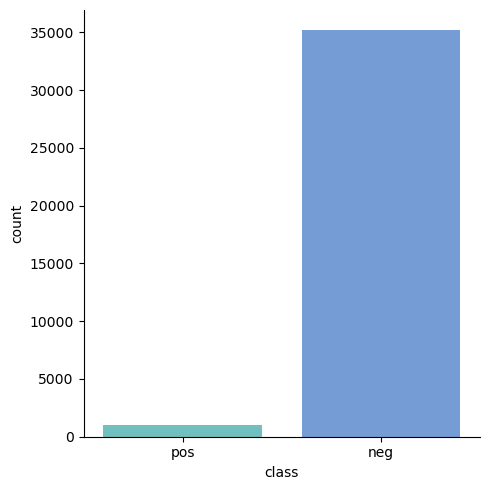

In [13]:
pos = df[df['class'] == 'pos'].shape[0]
neg = df[df['class'] == 'neg'].shape[0]

print("Positive:", pos, ", Negative:", neg)

sns.catplot(data=df, x="class", kind="count", palette="winter_r", alpha=0.6)
plt.show()


data is highly imbalanced so we have to  do some imputation and reshampling


# Create Function For Model Training And Evaluation


In [14]:
def evaluate_clf(true, predicted):
    """
    This function takes in true values and predicted values
    Returns: Accuracy, F1-Score, Precision, Recall, Roc-auc Score
    """
    acc = accuracy_score(true, predicted)  # Calculate Accuracy
    f1 = f1_score(true, predicted)  # Calculate F1-score
    precision = precision_score(true, predicted)  # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted)  # Calculate Roc
    return acc, f1, precision, recall, roc_auc

In [15]:

def total_cost(y_true, y_pred):
    """
    This function takes y_true, y_predicted, and prints Total cost due to misclassification
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = 10 * fp + 500 * fn
    return cost

In [34]:

def evaluate_models(X, y, models):
    """
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    """
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    results = []
    
    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Evaluating {name}")
        print(f"{'='*50}")
        
        model.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Training set performance
        train_accuracy, train_f1, train_precision, train_recall, train_rocauc = evaluate_clf(y_train, y_train_pred)
        train_cost = total_cost(y_train, y_train_pred)
        
        # Test set performance
        test_accuracy, test_f1, test_precision, test_recall, test_rocauc = evaluate_clf(y_test, y_test_pred)
        test_cost = total_cost(y_test, y_test_pred)
        
        print('Model performance for Training set')
        print(f"-- Accuracy: {train_accuracy:.4f}")
        print(f"-- F1 score: {train_f1:.4f}")
        print(f"-- Precision: {train_precision:.4f}")
        print(f"-- Recall: {train_recall:.4f}")
        print(f"-- Roc AUC Score: {train_rocauc:.4f}")
        print(f"-- COST: {train_cost}")
        
        print('-------------------')
        
        print('Model performance for Test set')
        print(f"-- Accuracy: {test_accuracy:.4f}")
        print(f"-- F1 score: {test_f1:.4f}")
        print(f"-- Precision: {test_precision:.4f}")
        print(f"-- Recall: {test_recall:.4f}")
        print(f"-- Roc AUC Score: {test_rocauc:.4f}")
        print(f"-- COST: {test_cost}")
        print('='*35)
        
        # Store results
        results.append({
            'Model Name': name,
            'Train_Accuracy': train_accuracy,
            'Train_F1': train_f1,
            'Test_Accuracy': test_accuracy,
            'Test_F1': test_f1,
            'Test_Precision': test_precision,
            'Test_Recall': test_recall,
            'Test_ROC_AUC': test_rocauc,
            'Cost': test_cost
        })
    
    # Create report DataFrame
    report = pd.DataFrame(results)
    report = report.sort_values(by="Cost")
    
    return report

# PLot Distribution of ALL Indepedent  Numerical Variable

In [ ]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

plt.figure(figsize=(15, 100))
for i, col in enumerate(numeric_features):
    plt.subplot(60, 3, i+1)
    sns.histplot(x=df[col], color='indianred')
    plt.xlabel(col, weight='bold')
    plt.tight_layout()

AS per plotting most models are not Normally Distributed

In [20]:
# Splitting X and y for all Experiments
X = df.drop('class', axis=1)
y = df['class']

In [21]:
y = y.replace({'pos': 1, 'neg': 0})


# Experiment: 1 = KNN Imputer for Null values

Why Robust scaler and not Standard scaler?

Scaling the data using Robust scaler
Since most of the independent variables are not normally distributed we cannot use Standardscaler

Why Robust Scaler and not Minmax?

because most of the feature has outliers. So Minmax will scale data according to Max values which is outlier.
This Scalr removes the median and scales the data according to the quantile range (defaults to IQR: Interquartile Range). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile).

In [22]:
robustscaler = RobustScaler()
X1 = robustscaler.fit_transform(X)

# Why KNN Imputer?

- KNNImputer by scikit-learn is a widely used method to impute missing values. It is widely being observed as a replacement for traditional imputation techniques.
- KNNImputer helps to impute missing values present in the observations by finding the nearest neighbors with the Euclidean distance matrix.
- Here we iterates through different K values and get accuracy and choose best K values.

## Using the optimal n_neighbour value for KNN imputer

In [23]:
results=[]
# define imputer
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')
strategies = [str(i) for i in [1,3,5,7,9]]
for s in strategies:
    pipeline = Pipeline(steps=[('i', KNNImputer(n_neighbors=int(s))), ('m', LogisticRegression())])
    scores = cross_val_score(pipeline, X1, y, scoring='accuracy', cv=2, n_jobs=-1)
    results.append(scores)
print('n_neighbors=%s || accuracy (%.4f) '% (s, mean(scores)))

n_neighbors=9 || accuracy (0.7276) 


We can observe n_neighbors=3 able to produce highest accuracy

# Pipeline For KNN Imputer

In [24]:
num_features = X.select_dtypes(exclude="object").columns

# Fit the KNN imputer with selected K-value
knn_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=3)),
    ('RobustScaler', RobustScaler())
])

In [25]:
X_knn = knn_pipeline.fit_transform(X)

# Handling Imbalanced data

**SMOTE+TOMEK** is one of such a hybrid technique that aims to clean overlapping data points for each of the classes distributed in sample space.

- This method combines the SMOTE ability to generate synthetic data for minority class and Tomek Links ability to remove the data that are identified as Tomek links from the majority class
- To add new data of minority class

1. Choose random data from the minority class.
2. Calculate the distance between the random data and its k nearest neighbors.
3. Multiply the difference with a random number between 0 and 1, then add the result to the minority class as a synthetic sample.
4. Repeat step number 2–3 until the desired proportion of minority class is met.


- To remove the tomeK links of the majority class

1. Choose random data from the majority class.
2. If the random data's nearest neighbor is the data from the minority class (i.e. create the Tomek Link), then remove the Tomek Link.

- This is method instead of adding duplicate data it synthesises the new data based on the already avaliable classes. Hence we choose this as our imputer method for this problem.

In [27]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [28]:
from imblearn.combine import SMOTETomek

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority', n_jobs=-1)

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_knn, y)

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


# Initialize Default Model In A Dictonary

In [29]:
# Dictionary which contains models for experiment
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoost Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

# Fit KNN Imputed Data For Models In Dictonary 

In [35]:
report_knn=evaluate_models(X_res,y_res,models)


Evaluating Random Forest
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9924
-- F1 score: 0.9924
-- Precision: 0.9885
-- Recall: 0.9963
-- Roc AUC Score: 0.9924
-- COST: 13810

Evaluating Decision Tree
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9871
-- F1 score: 0.9871
-- Precision: 0.9825
-- Recall: 0.9919
-- Roc AUC Score: 0.9871
-- COST: 29740

Evaluating Gradient Boosting
Model performance for Training set
-- Accuracy: 0.9839
-- F1 score: 0.9840
-- Precision: 0.9803
-- Recall: 0.9876
-- Roc AUC Score: 0.9839
-- COST: 179060
-------------------
Model performance for Test set
-- Accuracy: 0.9843
-- F1 score: 0.9843
-- Precision: 0.9810
-- Recall: 

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model performance for Training set
-- Accuracy: 0.5881
-- F1 score: 0.6931
-- Precision: 0.5524
-- Recall: 0.9299
-- Roc AUC Score: 0.5880
-- COST: 1195510
-------------------
Model performance for Test set
-- Accuracy: 0.5813
-- F1 score: 0.6895
-- Precision: 0.5476
-- Recall: 0.9307
-- Roc AUC Score: 0.5817
-- COST: 296890

Evaluating K-Neighbors Classifier
Model performance for Training set
-- Accuracy: 0.9814
-- F1 score: 0.9816
-- Precision: 0.9707
-- Recall: 0.9927
-- Roc AUC Score: 0.9814
-- COST: 110900
-------------------
Model performance for Test set
-- Accuracy: 0.9744
-- F1 score: 0.9748
-- Precision: 0.9605
-- Recall: 0.9894
-- Roc AUC Score: 0.9744
-- COST: 39850

Evaluating XGBClassifier
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9964
-- F1 score: 0.9964
-- Precision: 0.9939
-- Recall: 0.9990
-- Roc 

In [36]:
report_knn

,Model Name,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1,Test_Precision,Test_Recall,Test_ROC_AUC,Cost
5,XGBClassifier,1.000000,1.000000,0.996437,0.996442,0.993896,0.999001,0.996439,3930
6,CatBoost Classifier,0.999020,0.999020,0.994370,0.994380,0.991629,0.997147,0.994373,10590
0,Random Forest,1.000000,1.000000,0.992375,0.992397,0.988533,0.996290,0.992378,13810
1,Decision Tree,1.000000,1.000000,0.987101,0.987149,0.982476,0.991868,0.987106,29740
4,K-Neighbors Classifier,0.981381,0.981593,0.974416,0.974770,0.960526,0.989442,0.974431,39850
2,Gradient Boosting,0.983911,0.983974,0.984250,0.984287,0.981009,0.987587,0.984254,44840
7,AdaBoost Classifier,0.974948,0.974989,0.975627,0.975631,0.974520,0.976744,0.975628,83290
3,Logistic Regression,0.588073,0.693060,0.581314,0.689498,0.547599,0.930661,0.581662,296890


# Insights

- For the Experiment 1: Knn imputer has XGBoost classifier as the best Model
- Proceeding with further experiments

---

## Experiment:  2 = {Simple Imputer with Strategy Median} 

- **SimpleImputer** is a class in the `sklearn.impute` module that can be used to replace missing values in a dataset, using a variety of input strategies.
- Here we use SimpleImputer can also be used to impute multiple columns at once by passing in a list of column names. SimpleImputer will then replace missing values in all of the specified columns.

In [37]:
num_features = X.select_dtypes(exclude="object").columns

# Fit the Simple imputer with strategy median
median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('RobustScaler', RobustScaler())
])

In [38]:

# Fit X with median_pipeline
X_median = median_pipeline.fit_transform(X)

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority')
# Fit the model to generate the output.
X_res, y_res = smt.fit_resample(X_median, y)

# Training the models
report_median = evaluate_models(X_res, y_res, models)



Evaluating Random Forest
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9917
-- F1 score: 0.9918
-- Precision: 0.9863
-- Recall: 0.9973
-- Roc AUC Score: 0.9916
-- COST: 10480

Evaluating Decision Tree
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9856
-- F1 score: 0.9858
-- Precision: 0.9803
-- Recall: 0.9914
-- Roc AUC Score: 0.9855
-- COST: 31910

Evaluating Gradient Boosting
Model performance for Training set
-- Accuracy: 0.9840
-- F1 score: 0.9840
-- Precision: 0.9813
-- Recall: 0.9867
-- Roc AUC Score: 0.9840
-- COST: 190760
-------------------
Model performance for Test set
-- Accuracy: 0.9810
-- F1 score: 0.9812
-- Precision: 0.9757
-- Recall: 

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model performance for Training set
-- Accuracy: 0.6307
-- F1 score: 0.7150
-- Precision: 0.5813
-- Recall: 0.9286
-- Roc AUC Score: 0.6314
-- COST: 1185590
-------------------
Model performance for Test set
-- Accuracy: 0.6268
-- F1 score: 0.7147
-- Precision: 0.5817
-- Recall: 0.9266
-- Roc AUC Score: 0.6242
-- COST: 306620

Evaluating K-Neighbors Classifier
Model performance for Training set
-- Accuracy: 0.9789
-- F1 score: 0.9791
-- Precision: 0.9683
-- Recall: 0.9902
-- Roc AUC Score: 0.9789
-- COST: 146570
-------------------
Model performance for Test set
-- Accuracy: 0.9718
-- F1 score: 0.9724
-- Precision: 0.9596
-- Recall: 0.9854
-- Roc AUC Score: 0.9716
-- COST: 54430

Evaluating XGBClassifier
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 500
-------------------
Model performance for Test set
-- Accuracy: 0.9949
-- F1 score: 0.9950
-- Precision: 0.9916
-- Recall: 0.9984
-- Ro

# Report For Simple Imputer With Median Strategy

In [40]:
report_median[['Model Name','Cost']]

,Model Name,Cost
5,XGBClassifier,6100
6,CatBoost Classifier,6310
0,Random Forest,10480
1,Decision Tree,31910
2,Gradient Boosting,48240
4,K-Neighbors Classifier,54430
7,AdaBoost Classifier,87120
3,Logistic Regression,306620


Insights
For the Experiment 2: Simple imputer with median strategy has XGboost classifier as the best Model

Proceeding with further experiments

# Experiment: 3 = MICE for Imputing Null values
Code + Markdown

MICE stands for Multivariate Imputation By Chained Equations algorithm

This technique by which we can effortlessly impute missing values in a dataset by looking at data from other columns and trying to estimate the best prediction for each missing value.

ImputationKernel Creates a kernel dataset. This dataset can perform MICE on itself, and impute new data from models obtained during MICE.

In [42]:
!pip install miceforest

INFO: pip is looking at multiple versions of miceforest to determine which version is compatible with other requirements. This could take a while.
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 4.2 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.1 MB/s eta 0:00:00
Using cached dill-0.4.0-py3-none-any.whl (119 kB)


In [43]:
import miceforest as mf

X_mice = X.copy()
kernel = mf.ImputationKernel(
    X_mice,
    save_all_iterations=True,
    random_state=1989
)



In [44]:
X_mice = kernel.complete_data()

In [45]:
# fit robust scaler
mice_pipeline = Pipeline(steps=[
    ('RobustScaler', RobustScaler())
])

# Fit X with Mice imputer
X_mice = mice_pipeline.fit_transform(X_mice)

In [46]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority', n_jobs=-1)

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_mice, y)

# Training the models
report_mice = evaluate_models(X_res, y_res, models)

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(



Evaluating Random Forest
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9920
-- F1 score: 0.9921
-- Precision: 0.9883
-- Recall: 0.9959
-- Roc AUC Score: 0.9920
-- COST: 15330

Evaluating Decision Tree
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9822
-- F1 score: 0.9824
-- Precision: 0.9791
-- Recall: 0.9857
-- Roc AUC Score: 0.9822
-- COST: 51980

Evaluating Gradient Boosting
Model performance for Training set
-- Accuracy: 0.9854
-- F1 score: 0.9854
-- Precision: 0.9825
-- Recall: 0.9884
-- Roc AUC Score: 0.9854
-- COST: 166940
-------------------
Model performance for Test set
-- Accuracy: 0.9814
-- F1 score: 0.9815
-- Precision: 0.9772
-- Recall: 

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model performance for Training set
-- Accuracy: 0.6041
-- F1 score: 0.7072
-- Precision: 0.5608
-- Recall: 0.9570
-- Roc AUC Score: 0.6044
-- COST: 812050
-------------------
Model performance for Test set
-- Accuracy: 0.6001
-- F1 score: 0.7059
-- Precision: 0.5595
-- Recall: 0.9562
-- Roc AUC Score: 0.5987
-- COST: 207000

Evaluating K-Neighbors Classifier
Model performance for Training set
-- Accuracy: 0.9792
-- F1 score: 0.9795
-- Precision: 0.9677
-- Recall: 0.9915
-- Roc AUC Score: 0.9792
-- COST: 128270
-------------------
Model performance for Test set
-- Accuracy: 0.9704
-- F1 score: 0.9710
-- Precision: 0.9566
-- Recall: 0.9858
-- Roc AUC Score: 0.9703
-- COST: 53150

Evaluating XGBClassifier
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9959
-- F1 score: 0.9960
-- Precision: 0.9928
-- Recall: 0.9991
-- Roc A

In [47]:
report_mice[['Model Name','Cost']]

,Model Name,Cost
5,XGBClassifier,3510
6,CatBoost Classifier,8150
0,Random Forest,15330
2,Gradient Boosting,51120
1,Decision Tree,51980
4,K-Neighbors Classifier,53150
7,AdaBoost Classifier,93290
3,Logistic Regression,207000


# Insights
For the Experiment 3: Mice imputer has XGBoost classifier as the best Model

Proceeding with further experiments



# Experiment: 4 = Simple Imputer with Strategy Constant
Another strategy which can be used is replacing missing values with a fixed (constant) value.

To do this, specify "constant" for strategy and specify the fill value using the fill_value parameter

In [48]:
# Create a pipeline with simple imputer with strategy constant and fill value 0
constant_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('RobustScaler', RobustScaler())
])

X_const = constant_pipeline.fit_transform(X)

In [49]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority', n_jobs=-1)

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_const, y)

# training the models
report_const = evaluate_models(X_res, y_res, models)

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(



Evaluating Random Forest
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9932
-- F1 score: 0.9932
-- Precision: 0.9900
-- Recall: 0.9964
-- Roc AUC Score: 0.9931
-- COST: 13210

Evaluating Decision Tree
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9871
-- F1 score: 0.9872
-- Precision: 0.9819
-- Recall: 0.9926
-- Roc AUC Score: 0.9871
-- COST: 27290

Evaluating Gradient Boosting
Model performance for Training set
-- Accuracy: 0.9829
-- F1 score: 0.9829
-- Precision: 0.9798
-- Recall: 0.9861
-- Roc AUC Score: 0.9829
-- COST: 200690
-------------------
Model performance for Test set
-- Accuracy: 0.9807
-- F1 score: 0.9808
-- Precision: 0.9774
-- Recall: 

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model performance for Training set
-- Accuracy: 0.6693
-- F1 score: 0.7472
-- Precision: 0.6044
-- Recall: 0.9784
-- Roc AUC Score: 0.6695
-- COST: 482010
-------------------
Model performance for Test set
-- Accuracy: 0.6686
-- F1 score: 0.7478
-- Precision: 0.6046
-- Recall: 0.9800
-- Roc AUC Score: 0.6677
-- COST: 115570

Evaluating K-Neighbors Classifier
Model performance for Training set
-- Accuracy: 0.9803
-- F1 score: 0.9805
-- Precision: 0.9682
-- Recall: 0.9932
-- Roc AUC Score: 0.9803
-- COST: 105130
-------------------
Model performance for Test set
-- Accuracy: 0.9750
-- F1 score: 0.9754
-- Precision: 0.9626
-- Recall: 0.9885
-- Roc AUC Score: 0.9749
-- COST: 43200

Evaluating XGBClassifier
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 500
-------------------
Model performance for Test set
-- Accuracy: 0.9960
-- F1 score: 0.9960
-- Precision: 0.9929
-- Recall: 0.9991
-- Roc

# Report for Simple Imputer with Constant strategy

In [ ]:
report_const[['Model Name','Cost']]

# Insights
For the Experiment 4: Simple imputer with constant strategy has XGBoost classifier as the best Model

Proceeding with further experiments

# Experiment: 5 = Simple Imputer with Strategy Mean
Another strategy which can be used is replacing missing values with mean

Here we replace the missing values with the mean of the column

In [50]:
# Create a pipeline with Simple imputer with strategy mean
mean_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='mean')),
    ('RobustScaler', RobustScaler())
])

X_mean = mean_pipeline.fit_transform(X)

In [51]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority', n_jobs=-1)

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_mean, y)

# Training all models
report_mean = evaluate_models(X_res, y_res, models)


c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(



Evaluating Random Forest
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9937
-- F1 score: 0.9937
-- Precision: 0.9896
-- Recall: 0.9978
-- Roc AUC Score: 0.9938
-- COST: 8230

Evaluating Decision Tree
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 0
-------------------
Model performance for Test set
-- Accuracy: 0.9870
-- F1 score: 0.9869
-- Precision: 0.9844
-- Recall: 0.9895
-- Roc AUC Score: 0.9871
-- COST: 37590

Evaluating Gradient Boosting
Model performance for Training set
-- Accuracy: 0.9856
-- F1 score: 0.9857
-- Precision: 0.9828
-- Recall: 0.9886
-- Roc AUC Score: 0.9856
-- COST: 164880
-------------------
Model performance for Test set
-- Accuracy: 0.9864
-- F1 score: 0.9863
-- Precision: 0.9834
-- Recall: 0

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model performance for Training set
-- Accuracy: 0.6654
-- F1 score: 0.7334
-- Precision: 0.6107
-- Recall: 0.9176
-- Roc AUC Score: 0.6646
-- COST: 1323600
-------------------
Model performance for Test set
-- Accuracy: 0.6644
-- F1 score: 0.7312
-- Precision: 0.6050
-- Recall: 0.9238
-- Roc AUC Score: 0.6674
-- COST: 305810

Evaluating K-Neighbors Classifier
Model performance for Training set
-- Accuracy: 0.9816
-- F1 score: 0.9819
-- Precision: 0.9711
-- Recall: 0.9929
-- Roc AUC Score: 0.9816
-- COST: 107820
-------------------
Model performance for Test set
-- Accuracy: 0.9743
-- F1 score: 0.9743
-- Precision: 0.9611
-- Recall: 0.9879
-- Roc AUC Score: 0.9744
-- COST: 44770

Evaluating XGBClassifier
Model performance for Training set
-- Accuracy: 1.0000
-- F1 score: 1.0000
-- Precision: 1.0000
-- Recall: 1.0000
-- Roc AUC Score: 1.0000
-- COST: 500
-------------------
Model performance for Test set
-- Accuracy: 0.9967
-- F1 score: 0.9967
-- Precision: 0.9938
-- Recall: 0.9996
-- Ro

# Report for Simple imputer with strategy mean

In [52]:
report_mean[['Model Name','Cost']]

,Model Name,Cost
5,XGBClassifier,1930
6,CatBoost Classifier,6460
0,Random Forest,8230
1,Decision Tree,37590
2,Gradient Boosting,38660
4,K-Neighbors Classifier,44770
7,AdaBoost Classifier,90980
3,Logistic Regression,305810


# Experiment: 6-->Principle component analysis with imputing median
Principal component analysis is a technique for feature extraction — so it combines our input variables in a specific way, then we can drop the "least important" variables while still retaining the most valuable parts of all of the variables!

As the dataset has 164 columns we can try PCA and check our metrics Cost

In [53]:
from sklearn.decomposition import PCA

pca_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('RobustScaler', RobustScaler()),
    ('PCA', PCA())
])

In [54]:
X_pca = pca_pipeline.fit_transform(X)

# Applying PCA
from sklearn.decomposition import PCA
var_ratio = {}
for n in range(2, 150):
    pc = PCA(n_components=n)
    df_pca = pc.fit(X_pca)
    var_ratio[n] = sum(df_pca.explained_variance_ratio_)

# Variance Plot

<Axes: >

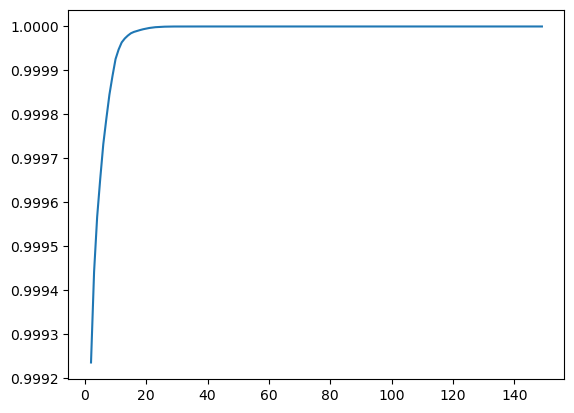

In [55]:
# plotting variance ratio
pd.Series(var_ratio).plot()

In [57]:
!pip install kneed

<Figure size 500x500 with 0 Axes>

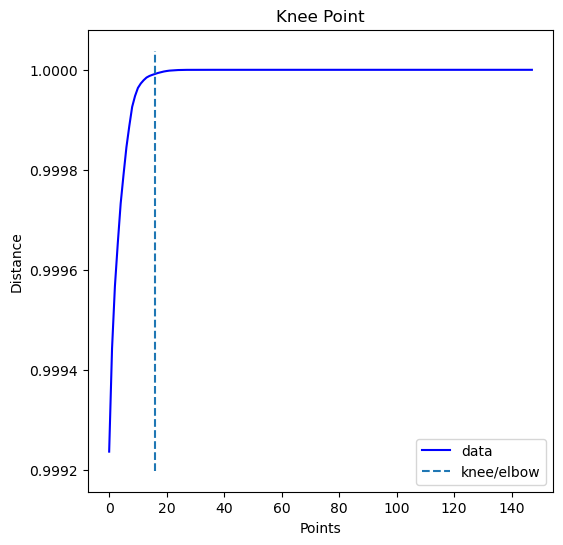

Knee Locator k = 18


In [58]:
from kneed import KneeLocator

i = np.arange(len(var_ratio))
variance_ratio = list(var_ratio.values())
components = list(var_ratio.keys())
knee = KneeLocator(i, variance_ratio, S=1, curve='concave', interp_method='polynomial')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()
k = components[knee.knee]
print('Knee Locator k =', k)

# PCA Elbow Detection
Automatically detects the optimal number of PCA components using the "elbow method." It plots explained variance ratios, applies the KneeLocator algorithm to identify where adding more components yields diminishing returns, and outputs the ideal component count (k) that balances dimensionality reduction with information retention

In [59]:
# Reducing the dimensions of the data
pca_final = PCA(n_components=18, random_state=42).fit(X_res)

reduced = pca_final.fit_transform(X_pca)

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority', n_jobs=-1)

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(reduced, y)


c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [60]:
# Training all models
report_pca = evaluate_models(X_res, y_res, models)


Evaluating Random Forest
Model performance for Training set
-- Accuracy: 0.9986
-- F1 score: 0.9986
-- Precision: 1.0000
-- Recall: 0.9972
-- Roc AUC Score: 0.9986
-- COST: 39010
-------------------
Model performance for Test set
-- Accuracy: 0.9826
-- F1 score: 0.9828
-- Precision: 0.9783
-- Recall: 0.9873
-- Roc AUC Score: 0.9826
-- COST: 46040

Evaluating Decision Tree
Model performance for Training set
-- Accuracy: 0.9986
-- F1 score: 0.9986
-- Precision: 1.0000
-- Recall: 0.9972
-- Roc AUC Score: 0.9986
-- COST: 39000
-------------------
Model performance for Test set
-- Accuracy: 0.9730
-- F1 score: 0.9732
-- Precision: 0.9708
-- Recall: 0.9756
-- Roc AUC Score: 0.9730
-- COST: 87560

Evaluating Gradient Boosting
Model performance for Training set
-- Accuracy: 0.9414
-- F1 score: 0.9412
-- Precision: 0.9436
-- Recall: 0.9387
-- Roc AUC Score: 0.9414
-- COST: 872160
-------------------
Model performance for Test set
-- Accuracy: 0.9376
-- F1 score: 0.9376
-- Precision: 0.9411
-- 

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model performance for Training set
-- Accuracy: 0.8750
-- F1 score: 0.8648
-- Precision: 0.9411
-- Recall: 0.7999
-- Roc AUC Score: 0.8750
-- COST: 2808490
-------------------
Model performance for Test set
-- Accuracy: 0.8727
-- F1 score: 0.8628
-- Precision: 0.9397
-- Recall: 0.7975
-- Roc AUC Score: 0.8730
-- COST: 714090

Evaluating K-Neighbors Classifier
Model performance for Training set
-- Accuracy: 0.9721
-- F1 score: 0.9723
-- Precision: 0.9632
-- Recall: 0.9816
-- Roc AUC Score: 0.9721
-- COST: 267980
-------------------
Model performance for Test set
-- Accuracy: 0.9640
-- F1 score: 0.9645
-- Precision: 0.9526
-- Recall: 0.9768
-- Roc AUC Score: 0.9639
-- COST: 84910

Evaluating XGBClassifier
Model performance for Training set
-- Accuracy: 0.9879
-- F1 score: 0.9879
-- Precision: 0.9871
-- Recall: 0.9887
-- Roc AUC Score: 0.9879
-- COST: 161110
-------------------
Model performance for Test set
-- Accuracy: 0.9788
-- F1 score: 0.9790
-- Precision: 0.9754
-- Recall: 0.9826
--

# FINAL MODEL

In [61]:
!pip install prettytable

In [62]:
from prettytable import PrettyTable

pt = PrettyTable()
pt.field_names = ["Model", "Imputation_method", "Total_cost"]
pt.add_row(["XGBClassifier", "Simple Imputer-Constant", "2950"])
pt.add_row(["XGBClassifier", "Mice", "3510"])
pt.add_row(["XGBClassifier", "Knn-Imputer", "4460"])
pt.add_row(["XGBClassifier", "Simple Imputer-Mean", "4950"])
pt.add_row(["CatBoostClassifier", "Median", "5760"])
pt.add_row(["Random Forest", "PCA", "34150"])
print(pt)

+--------------------+-------------------------+------------+
|       Model        |    Imputation_method    | Total_cost |
+--------------------+-------------------------+------------+
|   XGBClassifier    | Simple Imputer-Constant |    2950    |
|   XGBClassifier    |           Mice          |    3510    |
|   XGBClassifier    |       Knn-Imputer       |    4460    |
|   XGBClassifier    |   Simple Imputer-Mean   |    4950    |
| CatBoostClassifier |          Median         |    5760    |
|   Random Forest    |           PCA           |   34150    |
+--------------------+-------------------------+------------+


# Report
From the final report we can see that XGBClassifier with Simple imputer with strategy constant has performed the best with cost.

# Fitting the Final model and get reports

In [63]:
final_model = XGBClassifier()

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42, sampling_strategy='minority', n_jobs=-1)

# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_const, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

final_model = final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

c:\Users\Lenovo\OneDrive\Desktop\sensor live\Llivesensor\venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [64]:
print("Final XGBoost Classifier Accuracy Score (Train) :", final_model.score(X_train, y_train))
print("Final XGBoost Classifier Accuracy Score (Test) :", accuracy_score(y_test, y_pred))


Final XGBoost Classifier Accuracy Score (Train) : 0.9999821759589335
Final XGBoost Classifier Accuracy Score (Test) : 0.9960074148010837


In [65]:
print("Final XGBoost Classifier Cost Metric (Test) :", total_cost(y_test, y_pred))

Final XGBoost Classifier Cost Metric (Test) : 3500


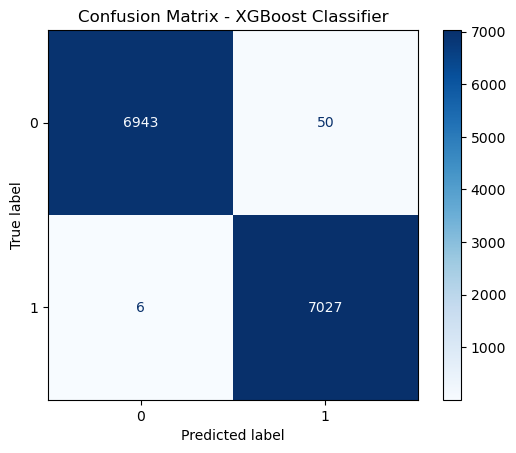

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - XGBoost Classifier")
plt.show()

# The best Model is XGBoost Classifier with 99.6% accuracy and cost of 2950